Dataset Loaded Successfully
Dataset Shape: (768, 9)
Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
Statistical Summary:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.

<Figure size 1200x600 with 0 Axes>

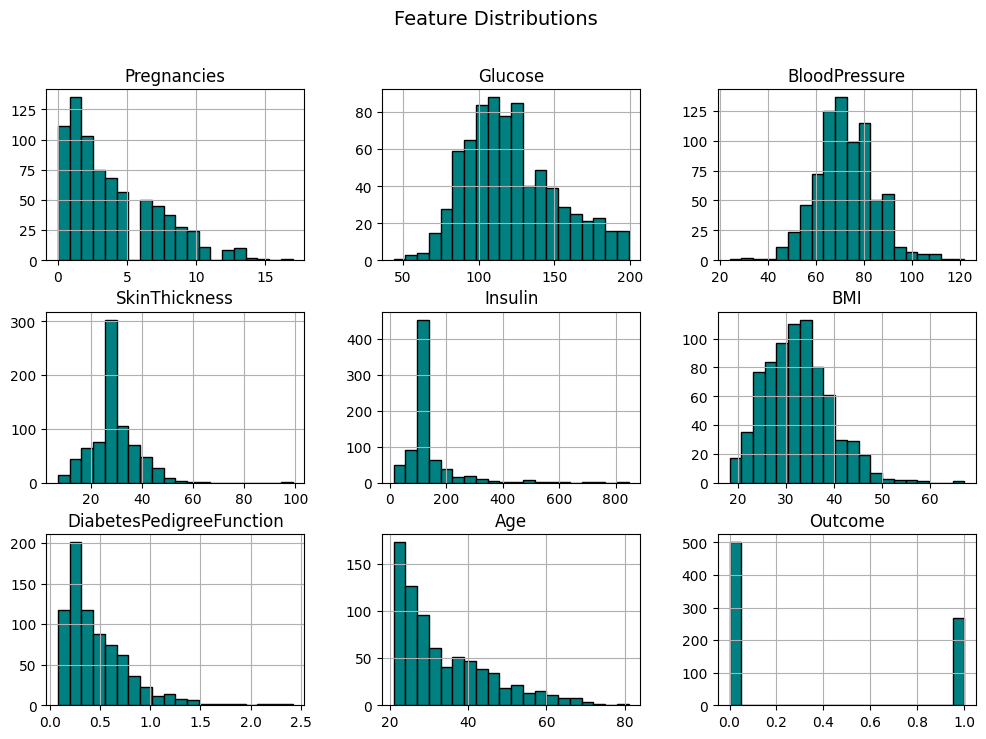

Correlation Matrix:
                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.128213       0.208615       0.081770   
Glucose                      0.128213  1.000000       0.218937       0.192615   
BloodPressure                0.208615  0.218937       1.000000       0.191892   
SkinThickness                0.081770  0.192615       0.191892       1.000000   
Insulin                      0.025047  0.419451       0.045363       0.155610   
BMI                          0.021559  0.231049       0.281257       0.543205   
DiabetesPedigreeFunction    -0.033523  0.137327      -0.002378       0.102188   
Age                          0.544341  0.266909       0.324915       0.126107   
Outcome                      0.221898  0.492782       0.165723       0.214873   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies               0.025047  0.021559                 -0.033523   
Glucose              

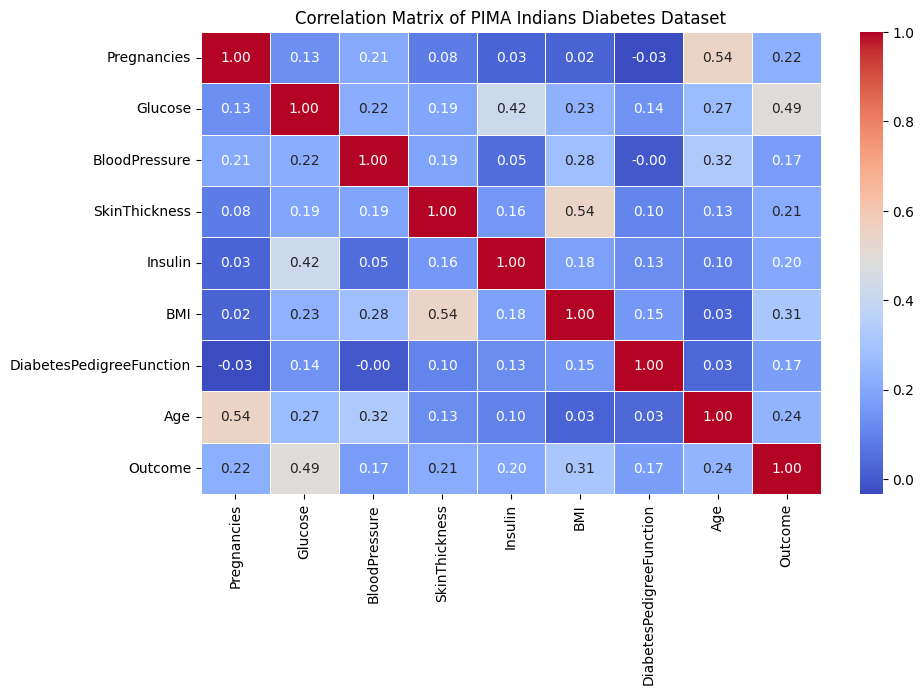

New features created: ['NF1', 'NF2', 'NF3', 'NF4']
Top 8 selected features: ['Pregnancies', 'Insulin', 'NF2', 'Age', 'BMI', 'NF4', 'Glucose', 'NF1']


/var/folders/60/bvmnpj31269dcz_9cvg4k2f40000gn/T/ipykernel_27852/500716416.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=selected_features, y=feature_scores[np.argsort(feature_scores)[-8:]], palette='viridis')


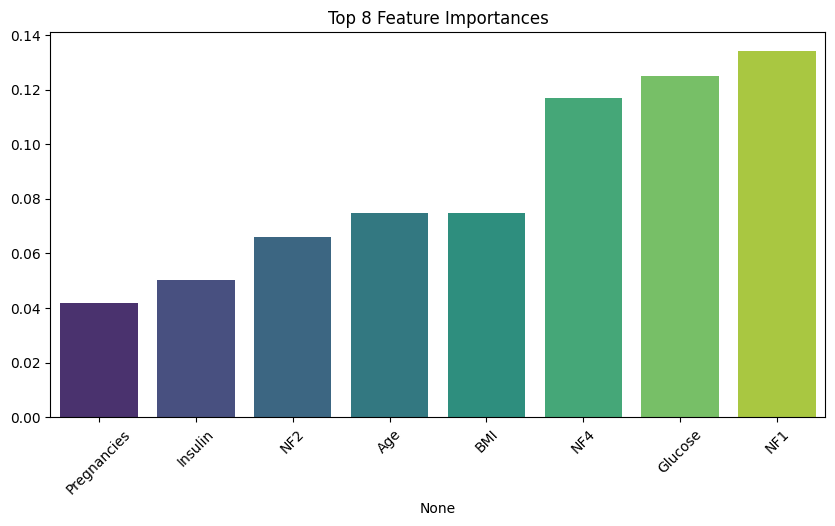

Dataset split into training and testing sets


/Users/admin/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Dataset balanced using SMOTE
Features standardized
Training model: Random Forest
Model: Random Forest
Accuracy: 0.7338
ROC-AUC: 0.8121
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       100
           1       0.61      0.69      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.72       154
weighted avg       0.74      0.73      0.74       154

Confusion Matrix:
[[76 24]
 [17 37]]
--------------------------------------------------


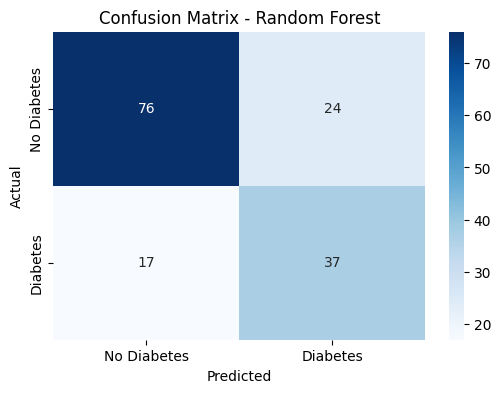

Training model: Gradient Boosting
Model: Gradient Boosting
Accuracy: 0.7468
ROC-AUC: 0.8206
              precision    recall  f1-score   support

           0       0.84      0.75      0.79       100
           1       0.62      0.74      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.76      0.75      0.75       154

Confusion Matrix:
[[75 25]
 [14 40]]
--------------------------------------------------


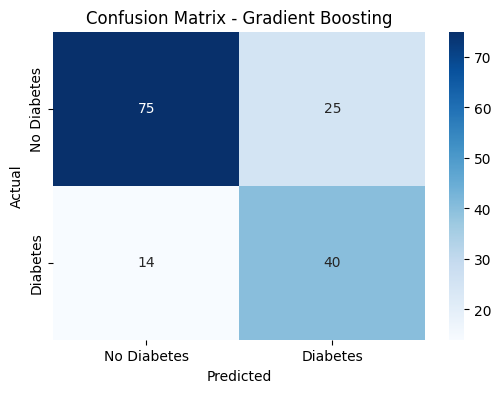

Training model: SVM
Model: SVM
Accuracy: 0.7208
ROC-AUC: 0.8172
              precision    recall  f1-score   support

           0       0.83      0.72      0.77       100
           1       0.58      0.72      0.64        54

    accuracy                           0.72       154
   macro avg       0.70      0.72      0.71       154
weighted avg       0.74      0.72      0.73       154

Confusion Matrix:
[[72 28]
 [15 39]]
--------------------------------------------------


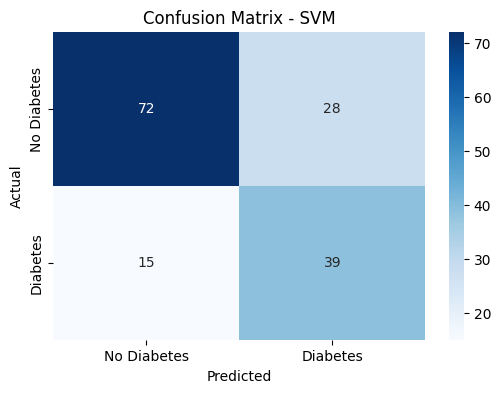

Training model: ANN
Model: ANN
Accuracy: 0.7662
ROC-AUC: 0.8226
              precision    recall  f1-score   support

           0       0.85      0.78      0.81       100
           1       0.65      0.74      0.69        54

    accuracy                           0.77       154
   macro avg       0.75      0.76      0.75       154
weighted avg       0.78      0.77      0.77       154

Confusion Matrix:
[[78 22]
 [14 40]]
--------------------------------------------------


/Users/admin/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


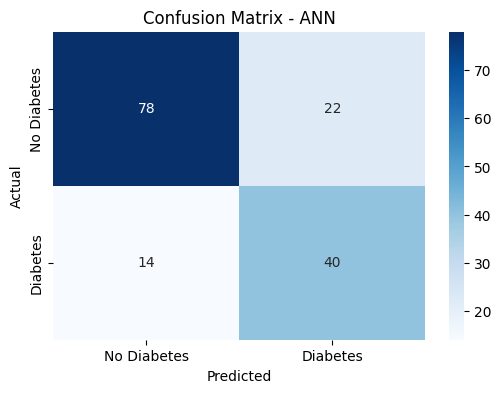

               Model  Accuracy   ROC-AUC
3                ANN  0.766234  0.822593
1  Gradient Boosting  0.746753  0.820556
0      Random Forest  0.733766  0.812130
2                SVM  0.720779  0.817222


,Model,Accuracy,ROC-AUC
3,ANN,0.766234,0.822593
1,Gradient Boosting,0.746753,0.820556
0,Random Forest,0.733766,0.812130
2,SVM,0.720779,0.817222


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import mutual_info_classif

# Load dataset
df = pd.read_csv("diabetes.csv")
print("Dataset Loaded Successfully")
print("Dataset Shape:", df.shape)
print("Column Information:")
print(df.info())
print("Statistical Summary:")
print(df.describe())

# Handling missing values (replacing 0s with NaN in relevant columns)
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)
df.fillna(df.median(), inplace=True)
print("Missing values handled")

# Visualizing Data Distribution
plt.figure(figsize=(12,6))
df.hist(bins=20, figsize=(12, 8), color='teal', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=14)
plt.show()

# Compute the correlation matrix
correlation_matrix = df.corr()

# Print the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of PIMA Indians Diabetes Dataset")
plt.show()

# Feature Engineering
# Creating new interaction features
df['NF1'] = df['BMI'] * df['Glucose']
df['NF2'] = df['Age'] * df['Insulin']
df['NF3'] = df['BloodPressure'] / df['BMI']
df['NF4'] = df['Glucose'] ** 2
print("New features created:", ['NF1', 'NF2', 'NF3', 'NF4'])

# Feature Selection using Mutual Information
X = df.drop(columns=['Outcome'])
y = df['Outcome']
feature_scores = mutual_info_classif(X, y)
selected_features = X.columns[np.argsort(feature_scores)[-8:]]  # Top 8 features
print("Top 8 selected features:", selected_features.tolist())

# Visualizing Feature Importance
plt.figure(figsize=(10, 5))
sns.barplot(x=selected_features, y=feature_scores[np.argsort(feature_scores)[-8:]], palette='viridis')
plt.title("Top 8 Feature Importances")
plt.xticks(rotation=45)
plt.show()

X = X[selected_features]

# Splitting dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Dataset split into training and testing sets")

# Balancing dataset using SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print("Dataset balanced using SMOTE")

# Standardizing features
scaler = StandardScaler()
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test = scaler.transform(X_test)
print("Features standardized")

# Model Training and Evaluation
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "ANN": MLPClassifier(hidden_layer_sizes=(32, 16), activation='relu', solver='adam', max_iter=500, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"Training model: {name}")
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    class_report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    results[name] = {
        "Accuracy": accuracy,
        "ROC-AUC": roc_auc,
        "Classification Report": class_report,
        "Confusion Matrix": conf_matrix
    }
    
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(class_report)
    print("Confusion Matrix:")
    print(conf_matrix)
    print("-" * 50)
    
    # Visualizing Confusion Matrix
    plt.figure(figsize=(6,4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Visualizing Results
accuracy_scores = [results[m]["Accuracy"] for m in models.keys()]
roc_auc_scores = [results[m]["ROC-AUC"] for m in models.keys()]

 

# Creating a DataFrame to tabulate results
results_df = pd.DataFrame({
    'Model': list(models.keys()),
    'Accuracy': accuracy_scores,
    'ROC-AUC': roc_auc_scores
})

# Sorting by Accuracy in descending order
results_df = results_df.sort_values(by='Accuracy', ascending=False)

# Print the sorted table
print(results_df)

# Optional: Display as a nicely formatted table if using Jupyter Notebook
from IPython.display import display
display(results_df)
